# Hudi VECTOR + BLOB + Vector Search — Spark SQL Variant

Same flow as [`hudi_sql_vector_blob_demo.py`](../hudi_sql_vector_blob_demo.py)
— every Hudi-touching operation is a SQL string so you see the actual
DDL/DML surface:

- `CREATE TABLE … (embedding VECTOR(N), image_bytes BLOB, …) USING hudi`
- `INSERT INTO … SELECT …, named_struct('type', 'INLINE', …)`
- `SELECT … FROM hudi_vector_search('<path>', 'embedding', ARRAY(…), k, 'cosine')`

Image loading (torchvision) and embedding generation (timm) stay in
Python — those can't be SQL. The bridge is a Spark temp view.

## 1. Toggles

In [1]:
# ===== EDIT THESE =====
BASE_FILE_FORMAT = "parquet"   # "parquet" or "lance"
N_SAMPLES        = 250
TOP_K            = 5
EMBEDDING_MODEL  = "mobilenetv3_small_100"

assert BASE_FILE_FORMAT in {"parquet", "lance"}

## 2. Pre-flight cleanup

In [2]:
# Wipe leftover Hudi/Spark state from previous runs.
#
# Why: `DROP TABLE IF EXISTS` only removes the catalog entry — the data dir
# and `.hoodie/` timeline at LOCATION persist across runs. A re-run would
# see old commits alongside new ones, and for the blob_reader notebook the
# shared `/tmp/pets_blob_container.bin` is overwritten by every blob_mode
# run, which leaves stale tables pointing past EOF (→ EOFException in
# BatchedBlobReader). Cleaning up at the top makes every cell run idempotent.
import shutil
from pathlib import Path

for pattern in [
    "/tmp/hudi_*_pets",
    "/tmp/pets_blob_container.bin",
    "/tmp/staging_pets_*.parquet",
]:
    for p in Path("/").glob(pattern.lstrip("/")):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        elif p.is_file():
            p.unlink(missing_ok=True)

shutil.rmtree("spark-warehouse", ignore_errors=True)
print("✓ Wiped /tmp/hudi_*_pets, /tmp/pets_blob_container.bin, staging Parquet, spark-warehouse")

✓ Wiped /tmp/hudi_*_pets, /tmp/pets_blob_container.bin, staging Parquet, spark-warehouse


## 3. Pre-JVM env (driver heap)

In [3]:
# Pre-JVM env: must run BEFORE any `pyspark` import so the driver heap is
# set at JVM launch time. PySpark in local mode can't grow the heap later
# via SparkSession.config().
import os

DRIVER_MEMORY = "4g"   # bump to "8g" or "12g" for N >= 2000

os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f"--driver-memory {DRIVER_MEMORY} --conf spark.driver.maxResultSize=2g pyspark-shell",
)

'--driver-memory 4g --conf spark.driver.maxResultSize=2g pyspark-shell'

## 4. Imports

In [4]:
import io
from pathlib import Path

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import torch
import timm
from sklearn.preprocessing import normalize
from PIL import Image

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet

from pyspark.sql import SparkSession
from IPython.display import Image as IPyImage, display

## 5. Configuration (derived from toggles)

In [5]:
CONFIG = {
    "dataset": "OxfordIIITPet",
    "table_path": f"/tmp/hudi_sql_{BASE_FILE_FORMAT}_pets",
    "table_name": f"pets_sql_{BASE_FILE_FORMAT}",
    "base_file_format": BASE_FILE_FORMAT,
    "n_samples": N_SAMPLES,
    "top_k": TOP_K,
    "embedding_model": EMBEDDING_MODEL,
    "output_dir": "./outputs",
    "panel_filename": f"hudi_sql_{BASE_FILE_FORMAT}_results.png",
}

BLOB_REFERENCE_CAST = "struct<external_path:string,offset:bigint,length:bigint,managed:boolean>"

for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

  dataset             : OxfordIIITPet
  table_path          : /tmp/hudi_sql_parquet_pets
  table_name          : pets_sql_parquet
  base_file_format    : parquet
  n_samples           : 250
  top_k               : 5
  embedding_model     : mobilenetv3_small_100
  output_dir          : ./outputs
  panel_filename      : hudi_sql_parquet_results.png


## 6. Resolve Hudi (and optionally Lance) jars

In [6]:
import sys
from pathlib import Path

def default_hudi_bundle_jar() -> str:
    # notebooks/ → vector_blob_demo/ → python/ → test/ → src/ →
    # hudi-examples-spark/ → hudi-examples/ → repo root.
    repo_root = Path.cwd().resolve().parents[6]
    return str(
        repo_root / "packaging" / "hudi-spark-bundle" / "target"
        / "hudi-spark3.5-bundle_2.12-1.2.0-SNAPSHOT.jar"
    )

def resolve_jars(base_file_format: str) -> str:
    hudi_jar = os.getenv("HUDI_BUNDLE_JAR", default_hudi_bundle_jar())
    if not Path(hudi_jar).is_file():
        sys.exit(f"ERROR: HUDI_BUNDLE_JAR does not exist at {hudi_jar}")
    if base_file_format != "lance":
        return hudi_jar
    lance_jar = os.getenv("LANCE_BUNDLE_JAR")
    if not lance_jar:
        sys.exit(
            "ERROR: LANCE_BUNDLE_JAR is not set (required when "
            "BASE_FILE_FORMAT='lance'). Grab "
            "org.lance:lance-spark-bundle-3.5_2.12:0.4.0 from Maven Central "
            "and export LANCE_BUNDLE_JAR=/abs/path/to/that.jar before launching jupyter."
        )
    if not Path(lance_jar).is_file():
        sys.exit(f"ERROR: LANCE_BUNDLE_JAR does not exist at {lance_jar}")
    return f"{hudi_jar},{lance_jar}"

## 7. Spark session

In [7]:
jars = resolve_jars(CONFIG["base_file_format"])

spark = (
    SparkSession.builder
    .appName("Hudi-SQL-Vector-Blob-Demo")
    .config("spark.jars", jars)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.sql.session.timeZone", "UTC")
    .config("hoodie.read.blob.inline.mode", "CONTENT")
    .config("spark.default.parallelism", "2")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("✓ Spark session ready")

26/04/27 16:05:36 WARN Utils: Your hostname, mac.lan resolves to a loopback address: 127.0.0.1; using 192.168.86.21 instead (on interface en0)
26/04/27 16:05:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/27 16:05:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 16:05:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


✓ Spark session ready


## 8. Load Oxford-IIIT Pet (pure Python)

Returns a list of dicts with PNG bytes + metadata, plus the breed class
names. This is the source data both the embedding step and the BLOB
column will draw from.

In [8]:
print(f"Loading dataset: Oxford-IIIT Pet ({CONFIG['n_samples']} samples)...")
root = os.path.expanduser("~/.cache/torchvision")
ds = OxfordIIITPet(root=root, split="trainval", download=True)
class_names = ds.classes

rng = np.random.default_rng()
n = min(CONFIG["n_samples"], len(ds))
indices = rng.choice(len(ds), size=n, replace=False)

data = []
for idx in indices:
    img, label = ds[int(idx)]
    img = img.convert("RGB")
    bio = io.BytesIO()
    img.save(bio, format="PNG")
    img_bytes = bio.getvalue()
    w, h = img.size
    category = class_names[label] if isinstance(class_names, list) else str(label)
    data.append({
        "image_id": f"pets_{int(idx):06d}",
        "category": category,
        "category_sanitized": category.replace("/", "_"),
        "label": int(label),
        "description": f"{category} from Oxford-IIIT Pet",
        "image_bytes_raw": img_bytes,
        "width": int(w),
        "height": int(h),
    })

print(f"✓ Loaded {len(data)} images")

Loading dataset: Oxford-IIIT Pet (250 samples)...
✓ Loaded 250 images


## 9. Embedding model (timm)

`num_classes=0` strips the classifier head so `model(x)` returns
feature vectors. We L2-normalize so cosine distance reduces to
`1 - dot_product`.

In [9]:
print(f"Loading embedding model: {CONFIG['embedding_model']}...")
model = timm.create_model(CONFIG["embedding_model"], pretrained=True, num_classes=0)
model.eval()
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)
print("✓ Model loaded")

print(f"Generating embeddings for {len(data)} images...")
images = [transform(Image.open(io.BytesIO(d["image_bytes_raw"])).convert("RGB"))
          for d in data]
batch = torch.stack(images)
with torch.no_grad():
    feats = model(batch).detach().cpu().numpy()
feats = normalize(feats)
for i, d in enumerate(data):
    d["embedding"] = feats[i].tolist()
embedding_dim = int(feats.shape[1])
print(f"✓ Generated embeddings (dimension: {embedding_dim})")

Loading embedding model: mobilenetv3_small_100...
✓ Model loaded
Generating embeddings for 250 images...
✓ Generated embeddings (dimension: 1024)


## 10. Stage Python data → Parquet (PyArrow) → Spark temp view

We bypass `spark.createDataFrame(...)` because in macOS local mode the
resulting `PythonRDD` saturates kernel socket buffers on binary
payloads. PyArrow writes Parquet in-process; Spark reads it back
JVM-natively.

In [10]:
STAGING_VIEW = "staging_pets"

arrow_schema = pa.schema([
    pa.field("image_id", pa.string(), nullable=False),
    pa.field("category", pa.string(), nullable=False),
    pa.field("category_sanitized", pa.string(), nullable=False),
    pa.field("label", pa.int32(), nullable=False),
    pa.field("description", pa.string(), nullable=True),
    pa.field("image_bytes_raw", pa.binary(), nullable=False),
    pa.field("width", pa.int32(), nullable=False),
    pa.field("height", pa.int32(), nullable=False),
    pa.field(
        "embedding",
        pa.list_(pa.field("element", pa.float32(), nullable=False),
                 list_size=embedding_dim),
        nullable=False,
    ),
])
columns = {
    "image_id": [d["image_id"] for d in data],
    "category": [d["category"] for d in data],
    "category_sanitized": [d["category_sanitized"] for d in data],
    "label": [int(d["label"]) for d in data],
    "description": [d.get("description") for d in data],
    "image_bytes_raw": [d["image_bytes_raw"] for d in data],
    "width": [int(d["width"]) for d in data],
    "height": [int(d["height"]) for d in data],
    "embedding": [d["embedding"] for d in data],
}
staging_path = f"/tmp/staging_{CONFIG['table_name']}_parquet.parquet"
pq.write_table(pa.table(columns, schema=arrow_schema), staging_path)
spark.read.parquet(staging_path).createOrReplaceTempView(STAGING_VIEW)
print(f"✓ Registered Spark temp view: {STAGING_VIEW}")

✓ Registered Spark temp view: staging_pets


## 11. CREATE TABLE — `VECTOR(N)` and `BLOB` are first-class

The `DefaultSparkRecordMerger` TBLPROPERTY is mandatory for Lance
(flips Hudi's writer factory from AVRO to SPARK). Harmless for
Parquet — safe to leave on always.

In [11]:
spark.sql(f"DROP TABLE IF EXISTS {CONFIG['table_name']}")

ddl = f"""
    CREATE TABLE {CONFIG['table_name']} (
        image_id            STRING,
        category            STRING,
        category_sanitized  STRING,
        label               INT,
        description         STRING,
        image_bytes         BLOB           COMMENT 'Pet image bytes (INLINE)',
        width               INT,
        height              INT,
        embedding           VECTOR({embedding_dim})
    ) USING hudi
    PARTITIONED BY (category_sanitized)
    LOCATION '{CONFIG['table_path']}'
    TBLPROPERTIES (
        primaryKey = 'image_id',
        preCombineField = 'image_id',
        type = 'cow',
        'hoodie.table.base.file.format' = '{CONFIG['base_file_format']}',
        'hoodie.write.record.merge.custom.implementation.classes' = 'org.apache.hudi.DefaultSparkRecordMerger'
    )
"""
print(ddl.strip())
spark.sql(ddl)
print(f"\n✓ Created table {CONFIG['table_name']} at {CONFIG['table_path']}")

CREATE TABLE pets_sql_parquet (
        image_id            STRING,
        category            STRING,
        category_sanitized  STRING,
        label               INT,
        description         STRING,
        image_bytes         BLOB           COMMENT 'Pet image bytes (INLINE)',
        width               INT,
        height              INT,
        embedding           VECTOR(1024)
    ) USING hudi
    PARTITIONED BY (category_sanitized)
    LOCATION '/tmp/hudi_sql_parquet_pets'
    TBLPROPERTIES (
        primaryKey = 'image_id',
        preCombineField = 'image_id',
        type = 'cow',
        'hoodie.table.base.file.format' = 'parquet',
        'hoodie.write.record.merge.custom.implementation.classes' = 'org.apache.hudi.DefaultSparkRecordMerger'
    )

✓ Created table pets_sql_parquet at /tmp/hudi_sql_parquet_pets


## 12. INSERT INTO ... SELECT — `named_struct` builds the BLOB INLINE struct

In [12]:
insert = f"""
    INSERT INTO {CONFIG['table_name']}
    SELECT
        image_id,
        category,
        category_sanitized,
        label,
        description,
        named_struct(
            'type',      'INLINE',
            'data',      image_bytes_raw,
            'reference', cast(null as {BLOB_REFERENCE_CAST})
        ) AS image_bytes,
        width,
        height,
        embedding
    FROM {STAGING_VIEW}
"""
spark.sql(insert)

# COUNT(image_id) — see findings.md for the Lance empty-projection bug.
count = spark.sql(
    f"SELECT COUNT(image_id) AS c FROM {CONFIG['table_name']}"
).collect()[0]["c"]
print(f"✓ Inserted {count} rows")

# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. Unable to attach even with module exceptions: [org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed.]
✓ Inserted 250 rows


## 13. Sample rows

In [13]:
spark.sql(f"""
    SELECT image_id, category, description
    FROM {CONFIG['table_name']}
    LIMIT 5
""").show(truncate=False)

+-----------+--------+---------------------------+
|image_id   |category|description                |
+-----------+--------+---------------------------+
|pets_003489|Sphynx  |Sphynx from Oxford-IIIT Pet|
|pets_003513|Sphynx  |Sphynx from Oxford-IIIT Pet|
|pets_001648|Sphynx  |Sphynx from Oxford-IIIT Pet|
|pets_001666|Sphynx  |Sphynx from Oxford-IIIT Pet|
|pets_003502|Sphynx  |Sphynx from Oxford-IIIT Pet|
+-----------+--------+---------------------------+



## 14. Vector search — `hudi_vector_search` TVF

The TVF requires the query vector as a constant expression, so we
inline 1024 floats as a literal `ARRAY(...)`. We ask for `top_k + 1`
because the query image itself is in the corpus (distance ≈ 0) and
gets skipped in the loop below.

In [14]:
query_idx = np.random.randint(len(data))
query_item = data[query_idx]
print(f"Query: {query_item['image_id']} ({query_item['category']})")

array_literal = "ARRAY(" + ", ".join(f"{float(v)}" for v in query_item["embedding"]) + ")"
query_sql = f"""
    SELECT image_id, category, image_bytes, _hudi_distance
    FROM hudi_vector_search(
        '{CONFIG['table_path']}',
        'embedding',
        {array_literal},
        {CONFIG['top_k'] + 1},
        'cosine'
    )
    ORDER BY _hudi_distance
"""
rows = spark.sql(query_sql).collect()

results = []
for row in rows:
    distance = float(row["_hudi_distance"])
    if distance < 0.001:   # skip the query image itself
        continue
    if len(results) >= CONFIG["top_k"]:
        break
    blob = row["image_bytes"]
    inline_bytes = blob["data"] if blob is not None else None
    results.append({
        "image_id": row["image_id"],
        "category": row["category"],
        "image_bytes": bytes(inline_bytes) if inline_bytes is not None else b"",
        "similarity": 1.0 - distance,
    })

print(f"\n✓ Top {len(results)} matches:")
for i, r in enumerate(results, 1):
    print(f"  {i}. {r['image_id']:18s} {r['category']:30s} sim={r['similarity']:.3f}")

Query: pets_003106 (Pug)

✓ Top 5 matches:
  1. pets_003093        Pug                            sim=0.569
  2. pets_000855        Japanese Chin                  sim=0.471
  3. pets_001277        Pug                            sim=0.448
  4. pets_002711        Japanese Chin                  sim=0.436
  5. pets_003109        Pug                            sim=0.430


## 15. Visualize — query + top-K panel

✓ Panel saved: outputs/hudi_sql_parquet_results.png


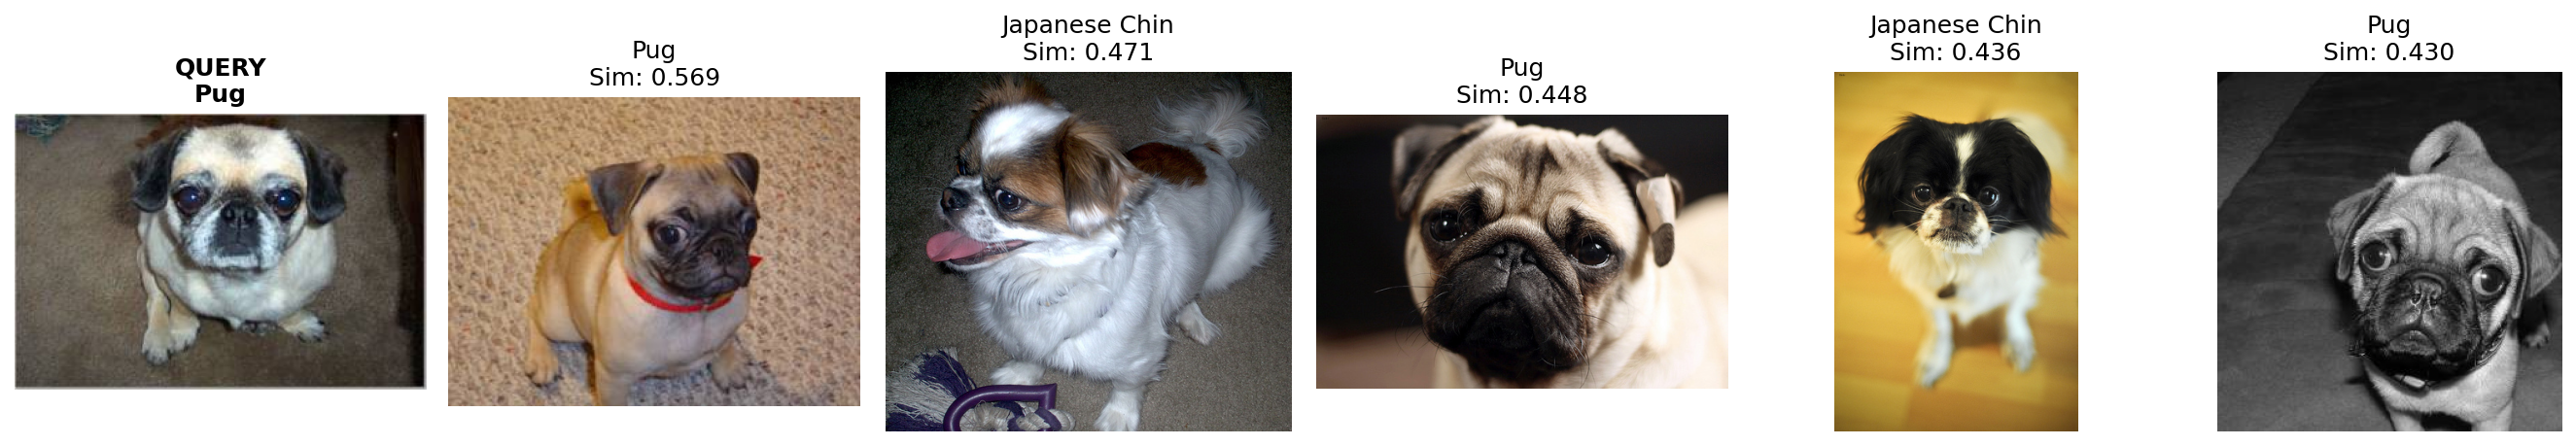

In [15]:
out_dir = Path(CONFIG["output_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

n_results = len(results)
fig, axes = plt.subplots(1, n_results + 1, figsize=(3 * (n_results + 1), 3.2))
query_img = Image.open(io.BytesIO(query_item["image_bytes_raw"])).convert("RGB")
axes[0].imshow(query_img)
axes[0].set_title(f"QUERY\n{query_item['category']}", fontweight="bold")
axes[0].axis("off")
for i, r in enumerate(results):
    img = Image.open(io.BytesIO(r["image_bytes"])).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"{r['category']}\nSim: {r['similarity']:.3f}")
    axes[i + 1].axis("off")
plt.tight_layout()
panel_path = out_dir / CONFIG["panel_filename"]
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"✓ Panel saved: {panel_path}")
display(IPyImage(filename=str(panel_path)))

## 16. Stop Spark (optional)

In [16]:
spark.stop()
print("✓ Spark stopped")

✓ Spark stopped
